PlayStation Rooms cafe

##### Imports

In [816]:
# Inter-arrival & service times: Exponential distribution (M/M/c queue model)
# Exponential chosen: memoryless, standard for independent random arrivals/service

import simpy # SimPy library for discrete-event simulation
import random # for random number generation
import numpy as np # for numerical operations(mean)
import matplotlib.pyplot as plt # for plotting results
random.seed(99)  # ensures same results every run for reproducibility

##### Configuration, dynamic lambda, shared data

In [817]:
# PS Café Configuration, parameters for the simulation
NUM_ROOMS    = 3   # 3 PS gaming rooms
BUFFER_SIZE  = 10  # max queue length 
SIM_DURATION = 17  # opening hours 10am -> 3am
DAYS         = 5  # simulate multiple days to get better stats
AVG_CUSTOMERS_PER_DAY = 50  # average customers per day, based on non-stationary arrival rates
TOTAL_CUSTOMERS = DAYS * AVG_CUSTOMERS_PER_DAY
WARMUP = 25  # 10% of 250, meaningful without wasting too much data
             # more appropriate for smaller simulations

# Non-stationary arrival rate (dynamic lambda) 
# avg customers per day = 2*11 + 6*4 + 2*2 = 50
def get_lambda(t):
    if   t < 11: return 2  # 10am-9pm low arrival rate
    elif t < 15: return 6  # 9pm-1am rush hours(biggest lambda)
    else:        return 2  # 1am-3am low arrival rate

# Shared data collectors
all_wait_times = []               # all customers wait times (transient + steady)
queue_log      = []               # queue length over time for plotting
room_busy      = [0.0, 0.0, 0.0]  # busy time per room(total hours each room was occupied)
dropped        = [0]              # customers dropped when buffer full (K=10), list so it can be modified: the element not the list itself is modified
room_counter   = [0]              # 0-1-2-0-1-2-... round-robin room assignment, to know which room to credit the busy time to

##### PS Café Class & customer_arrive()

In [818]:
class PSCafe:
    def __init__(self, env):
        self.env     = env   # simulation environment(SimPy)
        self.rooms = simpy.Resource(env, capacity=NUM_ROOMS) # PS gaming rooms as resources

    def gaming_session(self, room_idx):          
        #expovariate(rate=1/avg_time) returns a random value from an exponential distribution with the specified mean.
        #"recalculate the scale parameter (1/lambda) for the exponential RNG(continuous)""
        duration = random.expovariate(1/0.75)  # avg 45-min session
        """yield meaning: pause this process, let simulation/the event continue, and resume here after the timeout
              without yield everything runs instantly, no time passes
        """
        yield self.env.timeout(duration)  # simulate playing time, room occupied for this duration          
        room_busy[room_idx] += duration        # track busy time for this room, actual time spent
   

def customer_arrive(env, cust_id, cafe):
    arrival = env.now # current simulation clock time when customer arrives, float value in hours
    queue_log.append((env.now, len(cafe.rooms.queue)))  # log queue length at arrival time

    if len(cafe.rooms.queue) >= BUFFER_SIZE:    # buffer full -> drop customer
        dropped[0] += 1
        return

    with cafe.rooms.request() as req: # check all 3 rooms
        yield req                     # wait for free PS room, simpy will automatically queue if all rooms are busy(rooms.count=3)
        wait = env.now - arrival
        all_wait_times.append(wait)   # log all wait times then slice off warmup at output 

        idx = room_counter[0] % NUM_ROOMS  # round-robin room assignment
        room_counter[0] += 1               # increment for next customer
        yield env.process(cafe.gaming_session(idx)) # .queue, .request() and .process() are SimPy built-in methods 

##### Running Simulation Logic

In [ ]:
# Simulation Logic 

def run_cafe(env, cafe):                         
    cust_id = 0
    while cust_id < TOTAL_CUSTOMERS:              # run for DAYS × avg customers
        t = env.now % SIM_DURATION                # current hour within the day(0-17)
        if t >= 16:                               # stop new customers at 2am
            yield env.timeout(SIM_DURATION - t)  # skip to next day opening
            continue
        inter_arrival = random.expovariate(get_lambda(t))  # dynamic λ(t) , exponential is std model for random independent arrivals
        yield env.timeout(inter_arrival)           # wait until next customer
        env.process(customer_arrive(env, cust_id, cafe))   # spawn customer
        cust_id += 1

def main():
    env  = simpy.Environment()                    
    cafe = PSCafe(env)                         
    env.process(run_cafe(env, cafe))              
    env.run(until=DAYS * SIM_DURATION)  # stop at closing time where customers already inside finish, queue cleared at closing 

main()  # runs simulation, fills all_wait_times, queue_log...

##### Plot (queue length over time) & Output Analysis

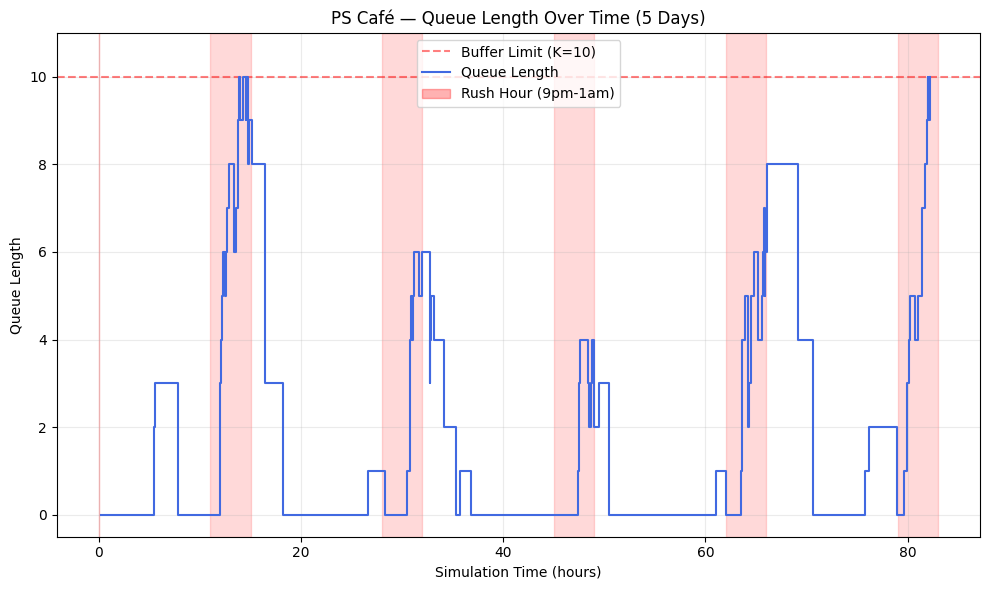

Total customers served : 237
Dropped customers (buffer full=10): 8
Drop rate : 3.3% 

Room busy times (hrs)  : [61.51, 49.78, 56.52]
Room utilization (%) : 68.0

── Warm-up Analysis ──
Avg Wait (Transient - includes warmup): 0.54 hrs = 32.5 mins
Avg Wait (Steady State - after warmup): 0.59 hrs = 35.4 mins


In [820]:
# Post-simulation analysis and plotting
# Extract times and queue lengths for plotting(unpack each (time, queue) pair into two separate lists)
times  = [t for t, q in queue_log] # extract times (x-axis)
queues = [q for t, q in queue_log] # extract queue lengths (y-axis)

# Plot
plt.figure(figsize=(10, 6))
plt.ylim(-0.5, BUFFER_SIZE + 1)   # y-axis show buffer limit clearly
plt.axhline(y=BUFFER_SIZE, color='red',  # show buffer limit line
            linestyle='--', alpha=0.5, label=f'Buffer Limit (K={BUFFER_SIZE})')
plt.step(times, queues, where='post', color='royalblue', linewidth=1.5, label='Queue Length') # step as queue changes at discrete times, post means the step is drawn after the time point (right-continuous)

# Shade ALL rush hour periods, area between x=11 and x=15 (every 17hrs one cycle)
for day in range(DAYS):
    plt.axvspan(day*SIM_DURATION + 11,          # rush start each day
                day*SIM_DURATION + 15,          # rush end each day
                alpha=0.15, color='red')

plt.axvspan(0, 0, alpha=0.3, color='red', label='Rush Hour (9pm-1am)') 
plt.xlabel('Simulation Time (hours)')
plt.ylabel('Queue Length')
plt.title(f'PS Café — Queue Length Over Time ({DAYS} Days)')
plt.grid(alpha=0.25)
plt.legend() # shows the labels box (Rush Hour, Queue Length)
plt.tight_layout() # auto-fixes spacing so nothing gets cut off
plt.show()

sim_end = max(times)
utilization = round(sum(room_busy) / (NUM_ROOMS * sim_end) * 100, 1)
drop_rate = round(dropped[0]/(dropped[0]+len(all_wait_times))*100, 1)

# Warm-up Analysis
transient_avg = np.mean(all_wait_times)            # include first 25
steady_avg    = np.mean(all_wait_times[WARMUP:])   # exclude first 25 
    

print(f"Total customers served : {len(all_wait_times)}")
print(f"Dropped customers (buffer full={BUFFER_SIZE}): {dropped[0]}")
print(f"Drop rate : {drop_rate}% \n")

print(f"Room busy times (hrs)  : {[round(b,2) for b in room_busy]}") # round to 2 decimals
print(f"Room utilization (%) : {utilization}")
print(f"\n── Warm-up Analysis ──") 
print(f"Avg Wait (Transient - includes warmup): {transient_avg:.2f} hrs = {transient_avg*60:.1f} mins")
print(f"Avg Wait (Steady State - after warmup): {steady_avg:.2f} hrs = {steady_avg*60:.1f} mins")

# ── How the initial "empty system" state skews the average? ──────────
# At simulation start, queue is empty and all rooms are idle.
# First customers wait 0 (or near 0), pulling the average DOWN artificially.
# This is "transient bias" / startup bias.
# Discarding first 25 customers removes this effect → steady state is more accurate.